#Network Dataset -Exploratory Data analysis
    -Understand the Dataset
    -Data cleaning 
    -Identify patterns
    -Prepare for further preprocessing a predictions 

This first cell import core python libraries that i will be utilizing to explore this data.

-pandas and numpy for data handing and some computations.
-matplotlib and seaborn for visualization.
-scikit-learn might come in handy as well.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing



Initally formating the data to see what it looks like. 

    -Shape: 352216 rows × 19 columns

In [70]:
cis = pd.read_csv(r"C:\Users\amira\Downloads\testbed_system_1_network_aggregated.csv")
cis



,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,source_port,source_mac,destination_ip,destination_port,destination_mac,source_key,destination_key,source_asset,destination_asset
0,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.857143,51,120,60,66,7,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.101,38055.0,e6:3f:ac:c9:a8:8c,84.3.251.18,84.3.251.101,NaN,NaN
1,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,71.600000,73,10,66,78,5,84.3.251.102,502.0,0a:fe:ec:47:74:fb,84.3.251.104,58691.0,4a:35:83:e0:3d:a4,84.3.251.102,84.3.251.104,NaN,NaN
2,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.000000,42,103,60,60,6,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.101,59827.0,e6:3f:ac:c9:a8:8c,84.3.251.18,84.3.251.101,NaN,NaN
3,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,60.857143,44,121,60,66,7,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.101,46691.0,e6:3f:ac:c9:a8:8c,84.3.251.18,84.3.251.101,NaN,NaN
4,2021-04-09 11:30:30+00:00,testbed_system_1,TCP,68.666667,103,105,66,74,6,84.3.251.102,54587.0,0a:fe:ec:47:74:fb,84.3.251.101,502.0,e6:3f:ac:c9:a8:8c,84.3.251.102,84.3.251.101,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352211,2022-02-21 15:13:30+00:00,testbed_system_1,TCP,60.000000,0,54,60,60,1,84.3.251.20,20043.0,00:0c:29:47:8c:0e,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,NaN
352212,2022-02-21 15:13:30+00:00,testbed_system_1,TCP,60.000000,0,55,60,60,1,84.3.251.20,24650.0,00:0c:29:47:8c:0e,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,NaN
352213,2022-02-21 15:13:30+00:00,testbed_system_1,TCP,60.000000,0,55,60,60,1,84.3.251.20,22935.0,00:0c:29:47:8c:0e,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,NaN
352214,2022-02-21 15:13:30+00:00,testbed_system_1,TCP,60.000000,0,55,60,60,1,84.3.251.20,20686.0,00:0c:29:47:8c:0e,84.3.251.18,502.0,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,NaN


##DataSet shape, colums and Data Types
    -  Each row represents a network communication flow captured in a specific time bucket.

   -This summary tells us the dataset is primarily numerical, with categorical fields that represent devices and protocols. The numerical fields are suitable for statistical analysis and correlation checks, while categorical fields will likely need encoding or grouping before modeling. We also identify potential “weak” columns (assets with NaNs) that may be dropped in preprocessing.

In [71]:
print("Shape of the dataset:", cis.shape)
print("\nColumns in the dataset:", cis.columns.tolist())
print("\nData types of each column:\n", cis.dtypes) 


Shape of the dataset: (352216, 19)

Columns in the dataset: ['bucket', 'system_id', 'protocol', 'avg_size', 'source_total_packets', 'destination_total_packets', 'min_size', 'max_size', 'num_connections', 'source_ip', 'source_port', 'source_mac', 'destination_ip', 'destination_port', 'destination_mac', 'source_key', 'destination_key', 'source_asset', 'destination_asset']

Data types of each column:
 bucket                        object
system_id                     object
protocol                      object
avg_size                     float64
source_total_packets           int64
destination_total_packets      int64
min_size                       int64
max_size                       int64
num_connections                int64
source_ip                     object
source_port                  float64
source_mac                    object
destination_ip                object
destination_port             float64
destination_mac               object
source_key                    object
destin

In [72]:

cis.describe(include='all')

,bucket,system_id,protocol,avg_size,source_total_packets,destination_total_packets,min_size,max_size,num_connections,source_ip,source_port,source_mac,destination_ip,destination_port,destination_mac,source_key,destination_key,source_asset,destination_asset
count,352216,352216,352216,352216.000000,3.522160e+05,3.522160e+05,352216.000000,352216.000000,3.522160e+05,351921,351852.000000,352216,351921,351852.000000,352216,352216,352216,0.0,0.0
unique,369,1,5,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,9,8,NaN,10,17,17,NaN,NaN
top,2022-02-21 15:12:00+00:00,testbed_system_1,TCP,NaN,NaN,NaN,NaN,NaN,NaN,84.3.251.20,NaN,00:0c:29:47:8c:0e,84.3.251.18,NaN,00:80:f4:03:fb:12,84.3.251.20,84.3.251.18,NaN,NaN
freq,62526,352216,273187,NaN,NaN,NaN,NaN,NaN,NaN,131608,NaN,130543,194207,NaN,193960,131608,194207,NaN,NaN
mean,NaN,NaN,NaN,64.750359,2.706656e+03,3.282224e+03,63.599348,66.605222,8.256279e+01,NaN,25092.643819,NaN,NaN,13531.056970,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,10.225423,3.226190e+05,3.282154e+05,9.498452,11.385492,3.486456e+03,NaN,21959.765926,NaN,NaN,21266.964857,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,60.000000,0.000000e+00,0.000000e+00,60.000000,60.000000,1.000000e+00,NaN,0.000000,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,60.000000,0.000000e+00,1.700000e+01,60.000000,60.000000,1.000000e+00,NaN,502.000000,NaN,NaN,502.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,60.000000,7.000000e+00,8.100000e+01,60.000000,60.000000,2.000000e+00,NaN,22345.000000,NaN,NaN,502.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,69.142857,4.400000e+01,1.100000e+02,66.000000,74.000000,5.000000e+00,NaN,45525.000000,NaN,NaN,35637.000000,NaN,NaN,NaN,NaN,NaN


 seeing if any colum Has differing values and if so? how many.

In [73]:
for col in cis.columns:
    print(f"{col}: {cis[col].nunique()} unique values")

bucket: 369 unique values
system_id: 1 unique values
protocol: 5 unique values
avg_size: 514 unique values
source_total_packets: 2528 unique values
destination_total_packets: 3231 unique values
min_size: 13 unique values
max_size: 19 unique values
num_connections: 453 unique values
source_ip: 8 unique values
source_port: 65029 unique values
source_mac: 9 unique values
destination_ip: 8 unique values
destination_port: 18921 unique values
destination_mac: 10 unique values
source_key: 17 unique values
destination_key: 17 unique values
source_asset: 0 unique values
destination_asset: 0 unique values


##Distribution of Destination_ips
    -The Histrogran below shows the frequency of each 'Destination_ip' value in the dataset.

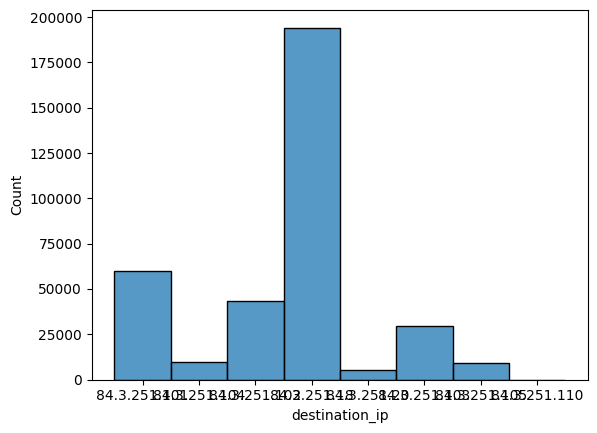

In [74]:
sns.histplot(cis['destination_ip'])
plt.show()



##Observation of null entries
    -We are going to need to decide how to handle missing values

In [75]:
cis.isnull().sum()



bucket                            0
system_id                         0
protocol                          0
avg_size                          0
source_total_packets              0
destination_total_packets         0
min_size                          0
max_size                          0
num_connections                   0
source_ip                       295
source_port                     364
source_mac                        0
destination_ip                  295
destination_port                364
destination_mac                   0
source_key                        0
destination_key                   0
source_asset                 352216
destination_asset            352216
dtype: int64

#Correlation Heatmap
    -The heatmap highlights strong relationshiops between all numerical features in the dataset
        -Each cell shows a correlation coefficient between -1 and 1
        1= perfect positive correlation
        0= no corrrelation
        -1= perfect negative correlation

    #USEFULLNESS
        -Since 'Source_total_packets', 'destination_total_packets' and 'num_connections' are pretty much identical in behavior. Maybe we dont need to keep all three. Can drop one or 2 to avoid redundancy and preserve predictive power
        -'source_asset' and 'destination_asset' have no correlation at all so could be dropped from this dataset

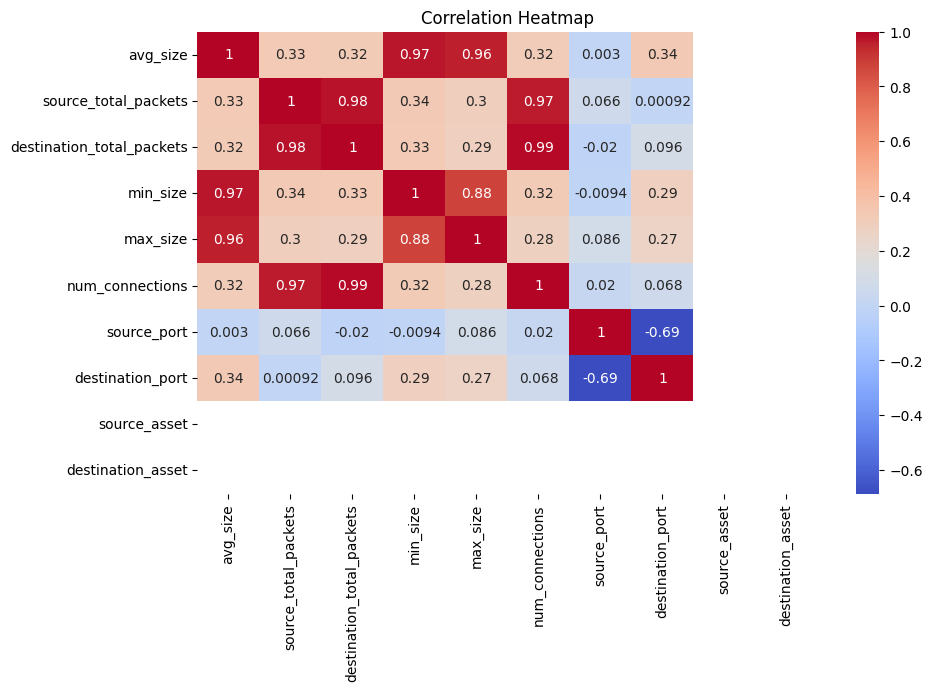

In [ ]:

plt.figure(figsize=(10,6))
numeric_cols = cis.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
